In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import scienceplots
import matplotlib.colors as colors
import multiprocessing
import warnings
import os
import colormaps as cmaps

from matplotlib.colors import Normalize
from nanonets.utils import BLUE_COLOR, RED_COLOR, get_net_currents, create_weighted_undirected_graph, display_net_flow_graph
from nanonets.utils import extract_harmonic_features, MC_effective_volume, get_displacement_currents, get_tau_f0_SET
from nanonets import Simulation
from scipy.interpolate import interp1d
from scipy.spatial import ConvexHull, KDTree
from scipy.spatial.distance import pdist
from scipy.stats import gaussian_kde
from tqdm.auto import tqdm
from scipy.optimize import curve_fit
from multiprocessing import Pool, cpu_count
from functools import partial

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="seaborn"
)

plt.style.use(["science","bright","grid"])
PATH    = "/home/j/j_mens07/bagheera/data/2_funding_period/dynamic/AC/regular/freq_manipulation_new/"
PATH_2  = "/home/j/j_mens07/bagheera/data/2_funding_period/dynamic/AC/regular/freq_manipulation_new_2/"
PATH_3  = "/home/j/j_mens07/bagheera/data/2_funding_period/dynamic/AC/regular/freq_manipulation_new_3/"

def get_lattice_electrode_cap_matrix(L: int):
    topo = {"Nx": L,"Ny": L,
            "e_pos": [[(L-1)//2, 0],[0, 0],[L-1, 0],
                    [0, (L-1)//2],[L-1, (L-1)//2],
                    [0, L-1],[L-1, L-1],[(L-1)//2, L-1]],
            "electrode_type": ['constant']*8}
    sim  = Simulation(topo)
    return sim.get_electrode_capacitance_matrix()

def data_abundance(y):
    y   = np.asarray(y)
    x   = np.sort(y)
    p_x = 1. * np.arange(len(x)) / float(len(x) - 1)
    ab  = 100 - 100*p_x
    return x, ab

def compute_thd(amplitudes):
    """
    Calculates Total Harmonic Distortion (THD).
    Input: Array of amplitudes [A_fund, A_harm1, A_harm2, ...]
    """
    if len(amplitudes) < 2 or amplitudes[0] == 0:
        return 0.0
        
    power_fund = amplitudes[0]**2
    power_harm = np.sum(amplitudes[1:]**2)
    
    return np.sqrt(power_harm) / np.sqrt(power_fund)

## Paramter and Input Time Series

In [3]:
N_PARTICLES     = [3,5,7,9,11,13,15]
N_PERIODS       = 100
N_SAMPLES       = 608
SAMPLE_P_PERIOD = 40
N_EQ_PERIODS    = 80

F0              = {3: 146.1, 5: 73.0, 7: 34.4, 9: 20.1, 11: 12.4, 13: 8.4, 15: 6.0}
F0_2            = {3: 151.5, 5: 71.9, 7: 39.6, 9: 31.1, 11: 20.6, 13: 13.6, 15: 10.7}
F0_3            = {3: 162.0, 5: 72.9, 7: 44.7, 9: 26.0, 11: 17.5, 13: 12.2, 15: 8.4}
F0_HZ           = {key: val * 1e6 for key, val in F0.items()}
F0_HZ_1         = {key: val * 1e6 for key, val in F0_2.items()}
F0_HZ_2         = {key: val * 1e6 for key, val in F0_3.items()}
DT              = {key: 1 / (SAMPLE_P_PERIOD * val) for key, val in F0_HZ.items()}
DT_2            = {key: 1 / (SAMPLE_P_PERIOD * val) for key, val in F0_HZ_1.items()}
DT_3            = {key: 1 / (SAMPLE_P_PERIOD * val) for key, val in F0_HZ_2.items()}

AMPLITUDE_LIST      = {3: 0.0136, 4: 0.0188, 5: 0.0193, 6: 0.0227, 7: 0.0229, 8: 0.0259, 9: 0.0261, 10: 0.0284, 11: 0.0286, 12: 0.0305, 13: 0.0307, 14: 0.0324, 15: 0.0325}
AMPLITUDE_LIST_2    = {3: 0.0134, 4: 0.0182, 5: 0.0186, 6: 0.0213, 7: 0.0215, 8: 0.0235, 9: 0.0235, 10: 0.0249, 11: 0.0249, 12: 0.0257, 13: 0.0257, 14: 0.0264, 15: 0.0264}
AMPLITUDE_LIST_3    = {3: 0.0128, 4: 0.0166, 5: 0.0168, 6: 0.0185, 7: 0.0186, 8: 0.0195, 9: 0.0195, 10: 0.0200, 11: 0.0201, 12: 0.0203, 13: 0.0203, 14: 0.0205, 15: 0.0205}


AMPLITUDE       = {key: 2.0*val for key, val in AMPLITUDE_LIST.items()}
AMPLITUDE_2     = {key: 2.0*val for key, val in AMPLITUDE_LIST_2.items()}
AMPLITUDE_3     = {key: 2.0*val for key, val in AMPLITUDE_LIST_3.items()}
C_US            = {N : get_lattice_electrode_cap_matrix(N).T for N in N_PARTICLES}

### from bagheera

In [ ]:
# Storage for final results only
x, y_t, y_e, y_d, y = {}, {}, {}, {}, {}

for N in N_PARTICLES:
    # Initialize lists for this particle count
    x[N], y_t[N], y_e[N], y_d[N], y[N] = [], [], [], [], []
    
    # We use N_SAMPLES but check for file existence
    for i in tqdm(range(N_SAMPLES), desc=f"Processing N={N}", leave=False):
        try:
            # 1. Load the localized files
            # Note: Using .values immediately to avoid keeping DataFrames in RAM
            df_data = pd.read_csv(f"{PATH}Nx={N}_Ny={N}_Ne=8_{i}.csv")
            df_states = pd.read_csv(f"{PATH}mean_state_Nx={N}_Ny={N}_Ne=8_{i}.csv")
            
            # 2. Extract raw values
            # Using .copy() is usually not needed here as these are new arrays
            x_vals = df_data.loc[SAMPLE_P_PERIOD*N_EQ_PERIODS:,'E0'].values
            obs_vals = df_data.loc[SAMPLE_P_PERIOD*N_EQ_PERIODS:,'Observable'].values
            err_vals = df_data.loc[SAMPLE_P_PERIOD*N_EQ_PERIODS:,'Error'].values
            state_vals = df_states.iloc[SAMPLE_P_PERIOD*N_EQ_PERIODS:,8:].values 

            # 3. Physics Calculations
            disp_curr = get_displacement_currents(state_vals, C_US[N], DT[N])
            
            # 4. Append directly to final containers
            x[N].append(x_vals)
            y_t[N].append(obs_vals)
            y_e[N].append(err_vals)
            y_d[N].append(disp_curr)
            y[N].append(obs_vals + disp_curr) # Total current
            
            # df_data and df_states are cleared automatically at the end of this loop iteration
            
        except FileNotFoundError:
            continue
        except Exception as e:
            print(f"Error at N={N}, sample {i}: {e}")

    # 5. Optimization: Convert to NumPy arrays for faster math later
    # Only do this if all samples have the same time-length!
    x[N]    = np.array(x[N])
    y_t[N]  = np.array(y_t[N])
    y_e[N]  = np.array(y_e[N])
    y_d[N]  = np.array(y_d[N])
    y[N]    = np.array(y[N])

    np.savetxt(f"x_new_{N}.csv", x[N])
    np.savetxt(f"y_new_{N}.csv", y[N])
    np.savetxt(f"y_t_new_{N}.csv", y_t[N])
    np.savetxt(f"y_e_new_{N}.csv", y_e[N])
    np.savetxt(f"y_d_new_{N}.csv", y_d[N])

Processing N=3:   1%|▏         | 9/608 [00:02<02:12,  4.51it/s]

Error at N=3, sample 8: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.


Processing N=3:   9%|▊         | 52/608 [00:13<01:59,  4.65it/s]

In [4]:
# Storage for final results only
x_2, y_t_2, y_e_2, y_d_2, y_2 = {}, {}, {}, {}, {}

for N in N_PARTICLES:
    # Initialize lists for this particle count
    x_2[N], y_t_2[N], y_e_2[N], y_d_2[N], y_2[N] = [], [], [], [], []
    
    # We use N_SAMPLES but check for file existence
    for i in tqdm(range(N_SAMPLES), desc=f"Processing N={N}", leave=False):
        try:
            # 1. Load the localized files
            # Note: Using .values immediately to avoid keeping DataFrames in RAM
            df_data = pd.read_csv(f"{PATH_2}Nx={N}_Ny={N}_Ne=8_{i}.csv")
            df_states = pd.read_csv(f"{PATH_2}mean_state_Nx={N}_Ny={N}_Ne=8_{i}.csv")
            
            # 2. Extract raw values
            # Using .copy() is usually not needed here as these are new arrays
            x_vals = df_data.loc[SAMPLE_P_PERIOD*N_EQ_PERIODS:,'E0'].values
            obs_vals = df_data.loc[SAMPLE_P_PERIOD*N_EQ_PERIODS:,'Observable'].values
            err_vals = df_data.loc[SAMPLE_P_PERIOD*N_EQ_PERIODS:,'Error'].values
            state_vals = df_states.iloc[SAMPLE_P_PERIOD*N_EQ_PERIODS:,8:].values 

            # 3. Physics Calculations
            disp_curr = get_displacement_currents(state_vals, C_US[N], DT_2[N])
            
            # 4. Append directly to final containers
            x_2[N].append(x_vals)
            y_t_2[N].append(obs_vals)
            y_e_2[N].append(err_vals)
            y_d_2[N].append(disp_curr)
            y_2[N].append(obs_vals + disp_curr) # Total current
            
            # df_data and df_states are cleared automatically at the end of this loop iteration
            
        except FileNotFoundError:
            continue
        except Exception as e:
            print(f"Error at N={N}, sample {i}: {e}")

    # 5. Optimization: Convert to NumPy arrays for faster math later
    # Only do this if all samples have the same time-length!
    x_2[N]    = np.array(x_2[N])
    y_t_2[N]  = np.array(y_t_2[N])
    y_e_2[N]  = np.array(y_e_2[N])
    y_d_2[N]  = np.array(y_d_2[N])
    y_2[N]    = np.array(y_2[N])

    np.savetxt(f"x_new_{N}_2.csv", x_2[N])
    np.savetxt(f"y_new_{N}_2.csv", y_2[N])
    np.savetxt(f"y_t_new_{N}_2.csv", y_t_2[N])
    np.savetxt(f"y_e_new_{N}_2.csv", y_e_2[N])
    np.savetxt(f"y_d_new_{N}_2.csv", y_d_2[N])

In [5]:
# Storage for final results only
x_3, y_t_3, y_e_3, y_d_3, y_3 = {}, {}, {}, {}, {}

for N in N_PARTICLES:
    # Initialize lists for this particle count
    x_3[N], y_t_3[N], y_e_3[N], y_d_3[N], y_3[N] = [], [], [], [], []
    
    # We use N_SAMPLES but check for file existence
    for i in tqdm(range(N_SAMPLES), desc=f"Processing N={N}", leave=False):
        try:
            # 1. Load the localized files
            # Note: Using .values immediately to avoid keeping DataFrames in RAM
            df_data = pd.read_csv(f"{PATH_3}Nx={N}_Ny={N}_Ne=8_{i}.csv")
            df_states = pd.read_csv(f"{PATH_3}mean_state_Nx={N}_Ny={N}_Ne=8_{i}.csv")
            
            # 2. Extract raw values
            # Using .copy() is usually not needed here as these are new arrays
            x_vals = df_data.loc[SAMPLE_P_PERIOD*N_EQ_PERIODS:,'E0'].values
            obs_vals = df_data.loc[SAMPLE_P_PERIOD*N_EQ_PERIODS:,'Observable'].values
            err_vals = df_data.loc[SAMPLE_P_PERIOD*N_EQ_PERIODS:,'Error'].values
            state_vals = df_states.iloc[SAMPLE_P_PERIOD*N_EQ_PERIODS:,8:].values 

            # 3. Physics Calculations
            disp_curr = get_displacement_currents(state_vals, C_US[N], DT_3[N])
            
            # 4. Append directly to final containers
            x_3[N].append(x_vals)
            y_t_3[N].append(obs_vals)
            y_e_3[N].append(err_vals)
            y_d_3[N].append(disp_curr)
            y_3[N].append(obs_vals + disp_curr) # Total current
            
            # df_data and df_states are cleared automatically at the end of this loop iteration
            
        except FileNotFoundError:
            continue
        except Exception as e:
            print(f"Error at N={N}, sample {i}: {e}")

    # 5. Optimization: Convert to NumPy arrays for faster math later
    # Only do this if all samples have the same time-length!
    x_3[N]    = np.array(x_3[N])
    y_t_3[N]  = np.array(y_t_3[N])
    y_e_3[N]  = np.array(y_e_3[N])
    y_d_3[N]  = np.array(y_d_3[N])
    y_3[N]    = np.array(y_3[N])

    np.savetxt(f"x_new_{N}_3.csv", x_3[N])
    np.savetxt(f"y_new_{N}_3.csv", y_3[N])
    np.savetxt(f"y_t_new_{N}_3.csv", y_t_3[N])
    np.savetxt(f"y_e_new_{N}_3.csv", y_e_3[N])
    np.savetxt(f"y_d_new_{N}_3.csv", y_d_3[N])

In [4]:
x   = {L : np.loadtxt(f"x_new_{L}.csv") for L in N_PARTICLES}
y   = {L : np.loadtxt(f"y_new_{L}.csv") for L in N_PARTICLES}
y_t = {L : np.loadtxt(f"y_t_new_{L}.csv") for L in N_PARTICLES}
y_e = {L : np.loadtxt(f"y_e_new_{L}.csv") for L in N_PARTICLES}
y_d = {L : np.loadtxt(f"y_d_new_{L}.csv") for L in N_PARTICLES}

x_2   = {L : np.loadtxt(f"x_new_{L}_2.csv") for L in N_PARTICLES}
y_2   = {L : np.loadtxt(f"y_new_{L}_2.csv") for L in N_PARTICLES}
y_t_2 = {L : np.loadtxt(f"y_t_new_{L}_2.csv") for L in N_PARTICLES}
y_e_2 = {L : np.loadtxt(f"y_e_new_{L}_2.csv") for L in N_PARTICLES}
y_d_2 = {L : np.loadtxt(f"y_d_new_{L}_2.csv") for L in N_PARTICLES}

x_3   = {L : np.loadtxt(f"x_new_{L}_3.csv") for L in N_PARTICLES}
y_3   = {L : np.loadtxt(f"y_new_{L}_3.csv") for L in N_PARTICLES}
y_t_3 = {L : np.loadtxt(f"y_t_new_{L}_3.csv") for L in N_PARTICLES}
y_e_3 = {L : np.loadtxt(f"y_e_new_{L}_3.csv") for L in N_PARTICLES}
y_d_3 = {L : np.loadtxt(f"y_d_new_{L}_3.csv") for L in N_PARTICLES}

/tmp/ipykernel_130873/3800752436.py:13: UserWarning: loadtxt: input contained no data: "x_new_11_3.csv"
  x_3   = {L : np.loadtxt(f"x_new_{L}_3.csv") for L in N_PARTICLES}
/tmp/ipykernel_130873/3800752436.py:14: UserWarning: loadtxt: input contained no data: "y_new_11_3.csv"
  y_3   = {L : np.loadtxt(f"y_new_{L}_3.csv") for L in N_PARTICLES}
/tmp/ipykernel_130873/3800752436.py:15: UserWarning: loadtxt: input contained no data: "y_t_new_11_3.csv"
  y_t_3 = {L : np.loadtxt(f"y_t_new_{L}_3.csv") for L in N_PARTICLES}
/tmp/ipykernel_130873/3800752436.py:16: UserWarning: loadtxt: input contained no data: "y_e_new_11_3.csv"
  y_e_3 = {L : np.loadtxt(f"y_e_new_{L}_3.csv") for L in N_PARTICLES}
/tmp/ipykernel_130873/3800752436.py:17: UserWarning: loadtxt: input contained no data: "y_d_new_11_3.csv"
  y_d_3 = {L : np.loadtxt(f"y_d_new_{L}_3.csv") for L in N_PARTICLES}


In [5]:
x_new   = {L : np.mean(x[L][:,:800].reshape(608, 4,5*SAMPLE_P_PERIOD), axis=1) for L in N_PARTICLES}
y_new   = {L : np.mean(y[L][:,:800].reshape(608, 4,5*SAMPLE_P_PERIOD), axis=1) for L in N_PARTICLES}
y_e_new = {L : np.sqrt((np.mean(y_e[L][:,:800].reshape(608, 4,5*SAMPLE_P_PERIOD)**2, axis=1))/5) for L in N_PARTICLES}

x_2_new     = {L : np.mean(x_2[L][:,:800].reshape(608, 4,5*SAMPLE_P_PERIOD), axis=1) for L in N_PARTICLES}
y_2_new     = {L : np.mean(y_2[L][:,:800].reshape(608, 4,5*SAMPLE_P_PERIOD), axis=1) for L in N_PARTICLES}
y_e_2_new   = {L : np.sqrt((np.mean(y_e_2[L][:,:800].reshape(608, 4,5*SAMPLE_P_PERIOD)**2, axis=1))/5) for L in N_PARTICLES}

x_3_new     = {L : np.mean(x_3[L][:,:800].reshape(608, 4,5*SAMPLE_P_PERIOD), axis=1) for L in N_PARTICLES if L != 11}
y_3_new     = {L : np.mean(y_3[L][:,:800].reshape(608, 4,5*SAMPLE_P_PERIOD), axis=1) for L in N_PARTICLES if L != 11}
y_e_3_new   = {L : np.sqrt((np.mean(y_e_3[L][:,:800].reshape(608, 4,5*SAMPLE_P_PERIOD)**2, axis=1))/5) for L in N_PARTICLES if L != 11}

## System Size Dependence

In [18]:
# Included higher Harmonics 
dim     = 5
n_vals  = np.arange(1, dim + 1, 1)

# Normalization
norm = True

# Storage
all_data_list = []

for N in N_PARTICLES:
    vecs = np.array([extract_harmonic_features(y_new[N][i], n_vals, mode='complex', pad_len=8192, interpolate=True, N_periods=5) 
                        for i in range(len(y_new[N]))])
    
    if norm:
        vecs_norm = vecs / vecs[:, 0, np.newaxis]
        features = vecs_norm[:, 2:]
    else:
        features = vecs
    all_data_list.append(features)

for N in N_PARTICLES:
    vecs = np.array([extract_harmonic_features(y_2_new[N][i], n_vals, mode='complex', pad_len=8192, interpolate=True, N_periods=5) 
                        for i in range(len(y_2_new[N]))])
    
    if norm:
        vecs_norm = vecs / vecs[:, 0, np.newaxis]
        features = vecs_norm[:, 2:]
    else:
        features = vecs
    all_data_list.append(features)

for N in N_PARTICLES:
    if N != 11:
        vecs = np.array([extract_harmonic_features(y_3_new[N][i], n_vals, mode='complex', pad_len=8192, interpolate=True, N_periods=5) 
                            for i in range(len(y_3_new[N]))])
        
        if norm:
            vecs_norm = vecs / vecs[:, 0, np.newaxis]
            features = vecs_norm[:, 2:]
        else:
            features = vecs
        all_data_list.append(features)

# Stack Data
all_data_stacked = np.vstack(all_data_list)    
if len(all_data_stacked) > 10_000:
    idx_sub = np.random.choice(len(all_data_stacked), 10_000, replace=False)
    dist_subset = all_data_stacked[idx_sub]
else:
    dist_subset = all_data_stacked

# Define Ruler
base_radius_unit = np.median(pdist(dist_subset))

In [19]:
side_lengths = all_data_stacked.max(axis=0)*1.05 - all_data_stacked.min(axis=0)*1.05
np.prod(side_lengths)

307.07401892628604

In [ ]:
def get_observable(points, base_radius_unit, d_factors, MC_samples):
    box_min = all_data_stacked.min(axis=0)*1.05
    box_max = all_data_stacked.max(axis=0)*1.05
    bounds  = (box_min, box_max)
    curve = []
    for d_factor in d_factors:
        current_radius = d_factor * base_radius_unit
        v = MC_effective_volume(points, MC_samples, current_radius, bounds)
        curve.append(v)
    return curve

def process_single_index(n, base_y_n, std_error_n, base_radius_unit, d_factors, MC_samples, M_resamples, norm, n_vals):
    """
    This function processes a single index 'n'. 
    It runs entirely on a single CPU core.
    """
    # 1. CRITICAL: Create a unique RNG for this specific process!
    # Using 'n' as part of the seed ensures reproducibility but independence between processes.
    rng = np.random.default_rng() 
    
    n_data = len(base_y_n)
    curves = []
    
    for m in range(M_resamples):
        # Select indices with resampling FIRST
        idx = rng.integers(0, n_data, n_data)
        
        # Apply independent noise
        sampled_y = base_y_n[idx]
        sampled_err = std_error_n[idx]
        perturbed_y = sampled_y + rng.normal(0.0, sampled_err)
        
        # Extract features
        vecs = np.array([
            extract_harmonic_features(
                perturbed_y[i], 
                n_vals, 
                mode='complex', 
                pad_len=8192, 
                interpolate=True,
                N_periods=5
            ) for i in range(n_data)
        ])
        
        if norm:
            vecs_norm = vecs / vecs[:, 0, np.newaxis]
            points = vecs_norm[:, 2:]
        else:
            points = vecs

        # Get observable
        curve = get_observable(points, base_radius_unit, d_factors, MC_samples)
        curves.append(curve)
        
    # Aggregate and return the results for this specific 'n'
    V_eff_mean = np.mean(curves, axis=0)
    V_eff_std = np.std(curves, axis=0)
    
    return n, V_eff_mean, V_eff_std


# --- Main Execution Block ---
if __name__ == '__main__':
    # Setup global variables
    MC_samples = int(1e2)
    M_resamples = int(1000)
    d_factors = np.logspace(-0.5, 0.6, 21)
    
    V_eff_means = {}
    V_eff_stds = {}
    
    # 1. Prepare the arguments for each task
    # We pack all the arguments needed for one run into a tuple
    tasks = []
    for n in N_PARTICLES:
        base_y_n = np.array(y_new[n])
        std_error_n = np.array(y_e_new[n]) / 1.96
        
        # Append as a tuple matching the function signature
        tasks.append((
            n, base_y_n, std_error_n, base_radius_unit, 
            d_factors, MC_samples, M_resamples, norm, n_vals
        ))

    # 2. Initialize the Pool with exactly 7 cores
    print("Starting multiprocessing pool with 7 workers...")
    with multiprocessing.Pool(processes=7) as pool:
        
        # pool.starmap automatically unpacks our tuples into the function arguments
        # It blocks until all 7 tasks are fully complete
        results = pool.starmap(process_single_index, tasks)
        
    # 3. Unpack the results
    for result_n, result_mean, result_std in results:
        V_eff_means[result_n] = result_mean
        V_eff_stds[result_n] = result_std
        print(f"Index {result_n} integrated successfully.")

    V_eff_means_2 = {}
    V_eff_stds_2 = {}
    
    # 1. Prepare the arguments for each task
    # We pack all the arguments needed for one run into a tuple
    tasks = []
    for n in N_PARTICLES:
        base_y_n = np.array(y_2_new[n])
        std_error_n = np.array(y_e_2_new[n]) / 1.96
        
        # Append as a tuple matching the function signature
        tasks.append((
            n, base_y_n, std_error_n, base_radius_unit, 
            d_factors, MC_samples, M_resamples, norm, n_vals
        ))

    # 2. Initialize the Pool with exactly 7 cores
    print("Starting multiprocessing pool with 7 workers...")
    with multiprocessing.Pool(processes=7) as pool:
        
        # pool.starmap automatically unpacks our tuples into the function arguments
        # It blocks until all 7 tasks are fully complete
        results = pool.starmap(process_single_index, tasks)
        
    # 3. Unpack the results
    for result_n, result_mean, result_std in results:
        V_eff_means_2[result_n] = result_mean
        V_eff_stds_2[result_n] = result_std
        print(f"Index {result_n} integrated successfully.")

    V_eff_means_3 = {}
    V_eff_stds_3 = {}

    # 1. Prepare the arguments for each task
    # We pack all the arguments needed for one run into a tuple
    tasks = []
    for n in N_PARTICLES:
        if n != 11:
            base_y_n = np.array(y_3_new[n])
            std_error_n = np.array(y_e_3_new[n]) / 1.96
            
            # Append as a tuple matching the function signature
            tasks.append((
                n, base_y_n, std_error_n, base_radius_unit, 
                d_factors, MC_samples, M_resamples, norm, n_vals
            ))

    # 2. Initialize the Pool with exactly 7 cores
    print("Starting multiprocessing pool with 7 workers...")
    with multiprocessing.Pool(processes=7) as pool:
        
        # pool.starmap automatically unpacks our tuples into the function arguments
        # It blocks until all 7 tasks are fully complete
        results = pool.starmap(process_single_index, tasks)
        
    # 3. Unpack the results
    for result_n, result_mean, result_std in results:
        V_eff_means_3[result_n] = result_mean
        V_eff_stds_3[result_n] = result_std
        print(f"Index {result_n} integrated successfully.")


    print("All indices processed!")

Starting multiprocessing pool with 7 workers...
Index 3 integrated successfully.
Index 5 integrated successfully.
Index 7 integrated successfully.
Index 9 integrated successfully.
Index 11 integrated successfully.
Index 13 integrated successfully.
Index 15 integrated successfully.
Starting multiprocessing pool with 7 workers...
Index 3 integrated successfully.
Index 5 integrated successfully.
Index 7 integrated successfully.
Index 9 integrated successfully.
Index 11 integrated successfully.
Index 13 integrated successfully.
Index 15 integrated successfully.
Starting multiprocessing pool with 7 workers...
Index 3 integrated successfully.
Index 5 integrated successfully.
Index 7 integrated successfully.
Index 9 integrated successfully.
Index 13 integrated successfully.
Index 15 integrated successfully.
All indices processed!


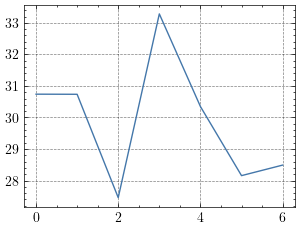

In [111]:
from scipy.interpolate import UnivariateSpline

def extract_inflection_point(gamma_vals, v_eff_curve):
    """
    Extracts the gamma value corresponding to the maximum growth rate (inflection point)
    of the Effective Volume curve using a smoothing spline.
    """
    # 1. Transform to log-space for stable spline fitting
    log_gamma = np.log10(gamma_vals)
    
    # 2. Fit a Smoothing Spline
    # 's' is the smoothing factor. s=0 is pure interpolation (hits every point). 
    # For MC data, a small positive 's' (e.g., 0.5 to 2.0) smooths out the noise.
    # You might need to tweak 's' depending on your MC variance.
    spline = UnivariateSpline(log_gamma, v_eff_curve, s=1.0)
    
    # 3. Extract the continuous first derivative
    deriv_1 = spline.derivative(n=1)
    
    # 4. Create a dense grid to precisely find the maximum of the derivative
    dense_log_gamma = np.linspace(log_gamma.min(), log_gamma.max(), 5000)
    growth_rates = deriv_1(dense_log_gamma)
    
   # 5. Find the inflection point (maximum growth rate)
    max_idx = np.argmax(growth_rates)
    optimal_log_gamma = dense_log_gamma[max_idx]
    
    # Convert back to linear gamma space
    optimal_gamma = 10**optimal_log_gamma
    
    # Calculate the V_eff at this exact gamma point using the spline
    optimal_v_eff = spline(optimal_log_gamma)
        
    return optimal_gamma, optimal_v_eff

plt.plot(np.array([extract_inflection_point(d_factors, V_eff_means[L]) for L in N_PARTICLES])[:,1])

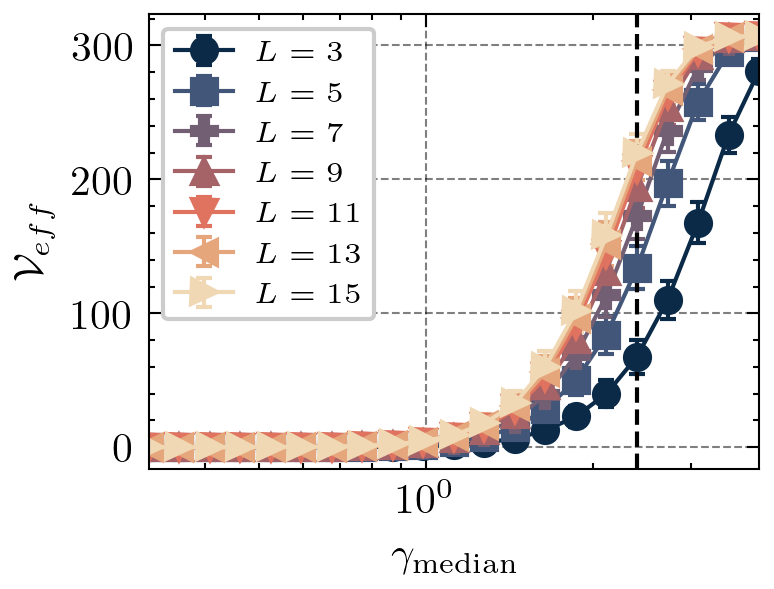

In [15]:
d_idx   = 16
mss     = ['o','s','P','^','v','<','>']
fig     = plt.figure(dpi=300)
ax      = fig.add_subplot()
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
p_norm  = Normalize(vmin=N_PARTICLES[0]-1, vmax=N_PARTICLES[-1]+1)

for i, N in enumerate(N_PARTICLES):
    _   = ax.errorbar(d_factors, V_eff_means[N], V_eff_stds[N], label=f"$L = {N}$", capsize=2, marker=mss[i], color=cmaps.lipari(p_norm(N)))
_   = ax.set_xlim(d_factors[0], d_factors[-1])
_   = ax.set_xlabel("$\gamma_\\textrm{median}$")
_   = ax.set_xscale('log')
_   = ax.set_ylabel("$\mathcal{V}_{eff}$")
_   = ax.legend(fontsize='x-small', loc='upper left', ncol=1)
_   = plt.axvline(d_factors[d_idx], color='black', ls='--')
# _   = ax.set_ylim(0,5000)

# fig.savefig(f"plots/png/V_eff_vs_gamma_median_system_size.png", transparent=False)
# fig.savefig(f"plots/pdf/V_eff_vs_gamma_median_system_size.pdf", transparent=False)
# fig.savefig(f"plots/svg/V_eff_vs_gamma_median_system_size.svg", transparent=True)

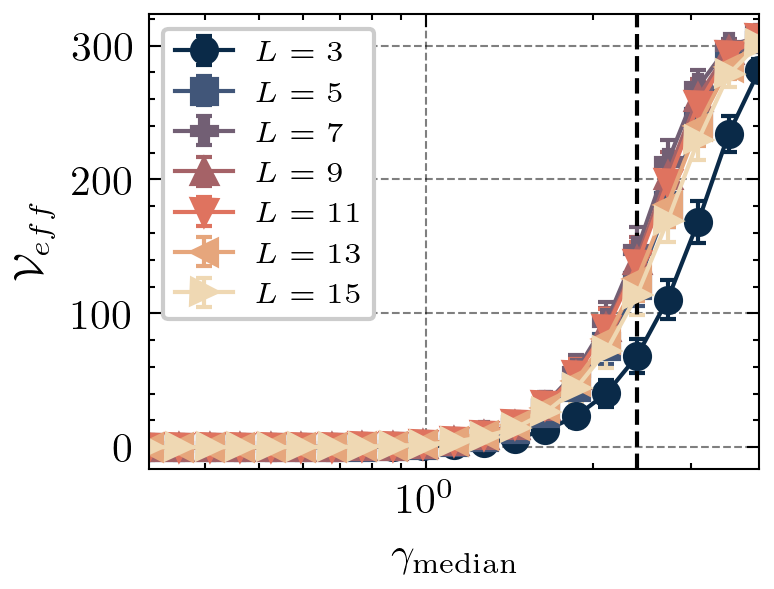

In [16]:
mss     = ['o','s','P','^','v','<','>']
fig     = plt.figure(dpi=300)
ax      = fig.add_subplot()
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
p_norm  = Normalize(vmin=N_PARTICLES[0]-1, vmax=N_PARTICLES[-1]+1)

for i, N in enumerate(N_PARTICLES):
    _   = ax.errorbar(d_factors, V_eff_means_2[N], V_eff_stds_2[N], label=f"$L = {N}$", capsize=2, marker=mss[i], color=cmaps.lipari(p_norm(N)))
_   = ax.set_xlim(d_factors[0], d_factors[-1])
_   = ax.set_xlabel("$\gamma_\\textrm{median}$")
_   = ax.set_xscale('log')
_   = ax.set_ylabel("$\mathcal{V}_{eff}$")
_   = ax.legend(fontsize='x-small', loc='upper left', ncol=1)
_   = plt.axvline(d_factors[d_idx], color='black', ls='--')
# _   = ax.set_ylim(0,5000)

# fig.savefig(f"plots/png/V_eff_vs_gamma_median_system_size_2.png", transparent=False)
# fig.savefig(f"plots/pdf/V_eff_vs_gamma_median_system_size_2.pdf", transparent=False)
# fig.savefig(f"plots/svg/V_eff_vs_gamma_median_system_size_2.svg", transparent=True)

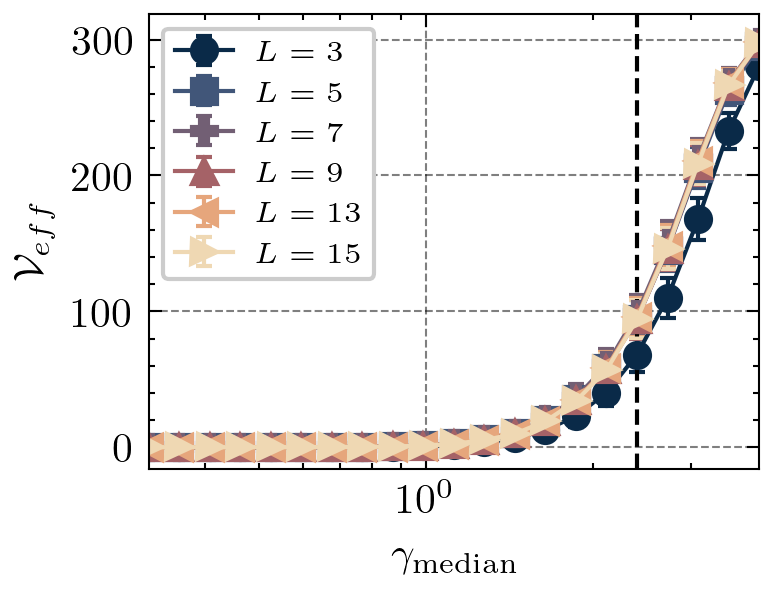

In [17]:
mss     = ['o','s','P','^','v','<','>']
fig     = plt.figure(dpi=300)
ax      = fig.add_subplot()
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
p_norm  = Normalize(vmin=N_PARTICLES[0]-1, vmax=N_PARTICLES[-1]+1)

for i, N in enumerate(N_PARTICLES):
    if N != 11:
        _   = ax.errorbar(d_factors, V_eff_means_3[N], V_eff_stds_3[N], label=f"$L = {N}$", capsize=2, marker=mss[i], color=cmaps.lipari(p_norm(N)))
_   = ax.set_xlim(d_factors[0], d_factors[-1])
_   = ax.set_xlabel("$\gamma_\\textrm{median}$")
_   = ax.set_xscale('log')
_   = ax.set_ylabel("$\mathcal{V}_{eff}$")
_   = ax.legend(fontsize='x-small', loc='upper left', ncol=1)
_   = plt.axvline(d_factors[d_idx], color='black', ls='--')
# _   = ax.set_ylim(0,5000)

# fig.savefig(f"plots/png/V_eff_vs_gamma_median_system_size_3.png", transparent=False)
# fig.savefig(f"plots/pdf/V_eff_vs_gamma_median_system_size_3.pdf", transparent=False)
# fig.savefig(f"plots/svg/V_eff_vs_gamma_median_system_size_3.svg", transparent=True)

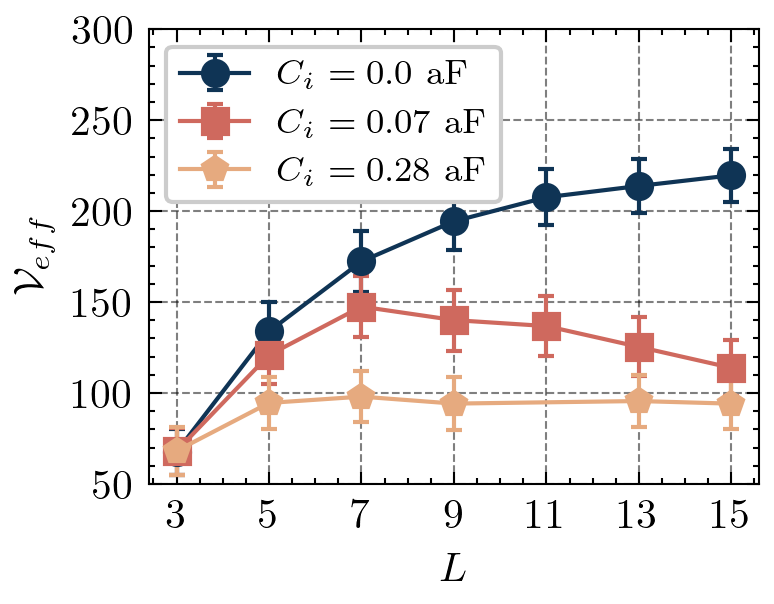

In [18]:
fig     = plt.figure(dpi=300)
ax      = fig.add_subplot()
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
_       = ax.errorbar(np.array(N_PARTICLES), [V_eff_means[N][d_idx] for i, N in enumerate(N_PARTICLES)],
                      [V_eff_stds[N][d_idx] for N in N_PARTICLES], marker='o', capsize=2, label='$C_i = 0.0~\mathrm{aF}$', color=cmaps.lipari(0.1))
_       = ax.errorbar(np.array(N_PARTICLES), [V_eff_means_2[N][d_idx] for i, N in enumerate(N_PARTICLES)],
                      [V_eff_stds_2[N][d_idx] for N in N_PARTICLES], marker='s', capsize=2, label='$C_i = 0.07~\mathrm{aF}$', color=cmaps.lipari(0.6))
_       = ax.errorbar([3,5,7,9,13,15], [V_eff_means_3[N][d_idx] for i, N in enumerate(N_PARTICLES) if N != 11],
                      [V_eff_stds_3[N][d_idx] for N in N_PARTICLES if N != 11], marker='p', capsize=2, label='$C_i = 0.28~\mathrm{aF}$', color=cmaps.lipari(0.8))


_       = ax.set_xlabel("$L$")
_       = ax.set_ylabel("$\mathcal{V}_{eff}$")
_       = ax.set_xticks(N_PARTICLES)
_       = ax.legend(fontsize='small', loc='upper left')
_       = ax.set_ylim(50,300)

# fig.savefig(f"plots/png/V_eff_vs_system_size.png", transparent=False)
# fig.savefig(f"plots/pdf/V_eff_vs_system_size.pdf", transparent=False)
# fig.savefig(f"plots/svg/V_eff_vs_system_size.svg", transparent=True)

### Phase Shift Output-Input

In [232]:
def get_phase_lag(response_signal: np.ndarray, input_signal: np.ndarray) -> float:
    """
    Calculates the Phase Lag between a system response and the driving input 
    at the fundamental driving frequencyme-domain snippet (maybe 3 or 4 AC cycles) of the raw Observable Tunneling Current (yt) side-by-side f
        Range is normalized to [-180, 180]. 
        Negative values indicate the response 'lags' behind the input (Capacitive).
        Positive values indicate the response 'leads' the input (Inductive).
    """
    
    # 1. Apply Windowing (Optional but recommended to reduce spectral leakage)
    # If your signal is an exact integer number of periods, you can skip this.
    # Otherwise, a Hanning window helps.
    # window = np.hanning(len(response_signal))
    # resp_w = response_signal * window
    # input_w = input_signal * window

    resp_w  = response_signal
    input_w  = input_signal
    
    # 2. Compute FFT
    # We use rfft because the signals are real-valued
    fft_resp = np.fft.rfft(resp_w)
    fft_in = np.fft.rfft(input_w)
    
    # 3. Find the Fundamental Frequency Index
    # We assume the input is a dominant sine wave, so we just find the max peak.
    # We skip index 0 (DC component).
    idx_fund = np.argmax(np.abs(fft_in[1:])) + 1
    
    # 4. Extract Angles (Phases) at that index
    angle_resp = np.angle(fft_resp[idx_fund])
    angle_in = np.angle(fft_in[idx_fund])
    
    # 5. Calculate Difference
    phase_diff = angle_resp - angle_in
        
    # 7. Normalize to [-180, 180] range
    # This handles wrap-around (e.g., if result is -270, it becomes +90)
    phase_diff = (phase_diff + np.pi) % (2 * np.pi) - np.pi
    
    return phase_diff / np.pi

In [233]:
phase_lags = {}
phase_lags_2 = {}
phase_lags_3 = {}
for N in N_PARTICLES:
    phase_lags[N] = []
    phase_lags_2[N] = []
    if N != 11:
        phase_lags_3[N] = []
    for i in range(N_SAMPLES):
        for j in range(100):
            phase_lags[N].append(get_phase_lag(y_new[N][i]+np.random.normal(0.0, y_e_new[N][i]/1.96), x_new[N][i]))
            phase_lags_2[N].append(get_phase_lag(y_2_new[N][i]+np.random.normal(0.0, y_e_2_new[N][i]/1.96), x_2_new[N][i]))
            if N != 11:
                phase_lags_3[N].append(get_phase_lag(y_3_new[N][i]+np.random.normal(0.0, y_e_3_new[N][i]/1.96), x_3_new[N][i]))

In [234]:
df          = pd.DataFrame(phase_lags).melt()
df['t']     = 1
df2         = pd.DataFrame(phase_lags_2).melt()
df2['t']    = 2
df3         = pd.DataFrame(phase_lags_3).melt()
df3['t']    = 3
df          = pd.concat([df, df2, df3], ignore_index=True)

df.head()

,variable,value,t
0,3,0.283078,1
1,3,0.281656,1
2,3,0.279034,1
3,3,0.279748,1
4,3,0.280619,1


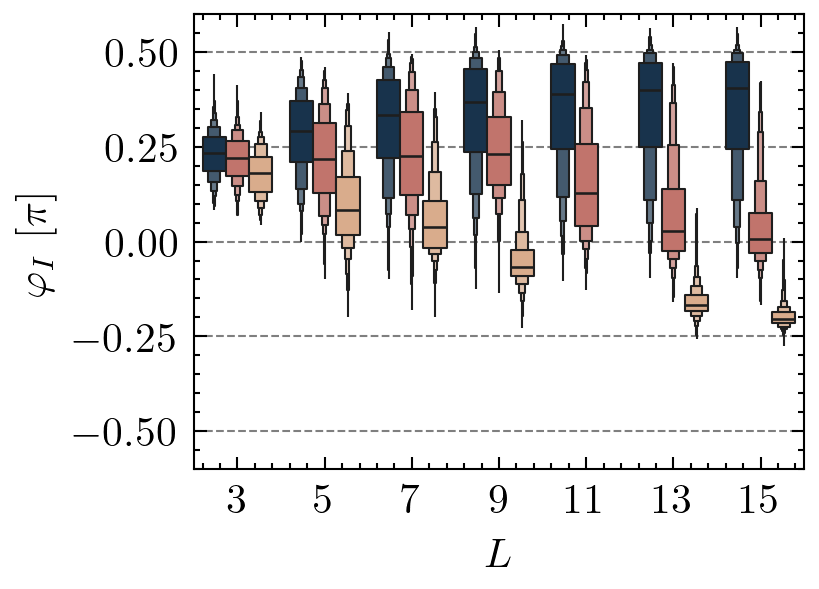

In [236]:
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
ax      = sns.boxenplot(data=df, x='variable', y='value',hue='t', ax=ax, showfliers=False,
                        palette=[cmaps.lipari(0.1), cmaps.lipari(0.6), cmaps.lipari(0.8)], legend=False)
_       = ax.set_xlabel("$L$")
_       = ax.set_ylabel("$\\varphi_{I}~[\mathrm{\pi}]$")
_       = ax.set_ylim(-0.6, 0.6)
# _       = ax.legend(['$C_i = 0.0~\mathrm{aF}$','$C_i = 0.07~\mathrm{aF}$','$C_i = 0.28~\mathrm{aF}$'], fontsize='small', loc='lower left')

fig.savefig(f"plots/pdf/I_phase_vs_L.pdf", transparent=False)
fig.savefig(f"plots/svg/I_phase_vs_L.svg", transparent=True)
fig.savefig(f"plots/png/I_phase_vs_L.png", transparent=False)

In [63]:
# fig, ax = plt.subplots(dpi=300)
# w, h    = fig.get_size_inches()
# scale   = 0.75
# _       = fig.set_size_inches(w * scale, h * scale)
# ax      = sns.violinplot(data=df, x='variable', y='value',hue='t', ax=ax, gridsize=300, split=False, inner=None, palette=[cmaps.lipari(0.6), cmaps.lipari(0.1)], density_norm='width', legend=False)
# _       = ax.set_xlabel("$L$")
# _       = ax.set_ylabel("$\\varphi_{I}~[\mathrm{\pi}]$")
# # _       = ax.set_ylim(-0.4, 0.4)
# # _       = ax.legend(['$C_i = 0.28~\mathrm{aF}$','$C_i = 0.07~\mathrm{aF}$'], fontsize='small', loc='lower left')

# # fig.savefig(f"plots/pdf/I_phase_vs_L.pdf", transparent=False)
# # fig.savefig(f"plots/svg/I_phase_vs_L.svg", transparent=True)
# # fig.savefig(f"plots/png/I_phase_vs_L.png", transparent=False)

### HH Phase Shift

In [237]:
N_BOOT = 20
data_boot = {}
data_boot_2 = {}
data_boot_3 = {}
for N in N_PARTICLES:
    data_boot[N] = []
    data_boot_2[N] = []
    if N != 11:
        data_boot_3[N] = []
    for i in range(N_SAMPLES):
        for _ in range(N_BOOT):
            data_boot[N].append(y_new[N][i]+np.random.normal(0,y_e_new[N][i] / 1.96))
            data_boot_2[N].append(y_2_new[N][i]+np.random.normal(0,y_e_2_new[N][i] / 1.96))
            if N != 11:
                data_boot_3[N].append(y_3_new[N][i]+np.random.normal(0,y_e_3_new[N][i] / 1.96))

In [238]:
# --- Configuration ---
phase_vectors   = {}
phase_vectors_2 = {}
phase_vectors_3 = {}
amp_vectors     = {}
amp_vectors_2   = {}
amp_vectors_3   = {}
dim             = 9
n_vals          = np.arange(2, dim + 1, 1)

# Get Phase
for N in N_PARTICLES:
    phase_vectors[N] = np.array([extract_harmonic_features(data_boot[N][i], n_vals, mode='phase', pad_len=8192, interpolate=True, N_periods=5) 
                     for i in range(N_SAMPLES*N_BOOT)]).flatten()
    amp_vectors[N] = np.array([extract_harmonic_features(data_boot[N][i], n_vals, mode='abs', pad_len=8192, interpolate=True, N_periods=5) 
                     for i in range(N_SAMPLES*N_BOOT)]).flatten()
    
    phase_vectors_2[N] = np.array([extract_harmonic_features(data_boot_2[N][i], n_vals, mode='phase', pad_len=8192, interpolate=True, N_periods=5) 
                     for i in range(N_SAMPLES*N_BOOT)]).flatten()
    amp_vectors_2[N] = np.array([extract_harmonic_features(data_boot_2[N][i], n_vals, mode='abs', pad_len=8192, interpolate=True, N_periods=5) 
                     for i in range(N_SAMPLES*N_BOOT)]).flatten()
    
    if N != 11:
        phase_vectors_3[N] = np.array([extract_harmonic_features(data_boot_3[N][i], n_vals, mode='phase', pad_len=8192, interpolate=True, N_periods=5) 
                        for i in range(N_SAMPLES*N_BOOT)]).flatten()
        amp_vectors_3[N] = np.array([extract_harmonic_features(data_boot_3[N][i], n_vals, mode='abs', pad_len=8192, interpolate=True, N_periods=5) 
                        for i in range(N_SAMPLES*N_BOOT)]).flatten()

In [239]:
dfs = []

n_samples = 5000

for i, N in enumerate(N_PARTICLES):
    a = phase_vectors[N]
    b = amp_vectors[N]
    p = b / b.sum()

    # Resample indices according to weights
    idx = np.random.choice(len(a), size=n_samples, p=p)
    
    df_resampled = pd.DataFrame({
        'a': a[idx],
        'N': str(N)
    })

    dfs.append(df_resampled)

df_all = pd.concat(dfs)
df_all['t'] = 1

dfs = []
for i, N in enumerate(N_PARTICLES):
    a = phase_vectors_2[N]
    b = amp_vectors_2[N]
    p = b / b.sum()

    # Resample indices according to weights
    idx = np.random.choice(len(a), size=n_samples, p=p)
    
    df_resampled = pd.DataFrame({
        'a': a[idx],
        'N': str(N)
    })

    dfs.append(df_resampled)

df_all2 = pd.concat(dfs)
df_all2['t'] = 2

dfs = []
for i, N in enumerate(N_PARTICLES):
    if N != 11:
        a = phase_vectors_3[N]
        b = amp_vectors_3[N]
        p = b / b.sum()

        # Resample indices according to weights
        idx = np.random.choice(len(a), size=n_samples, p=p)
        
        df_resampled = pd.DataFrame({
            'a': a[idx],
            'N': str(N)
        })

        dfs.append(df_resampled)

df_all3 = pd.concat(dfs)
df_all3['t'] = 3

df_all = pd.concat([df_all, df_all2, df_all3])

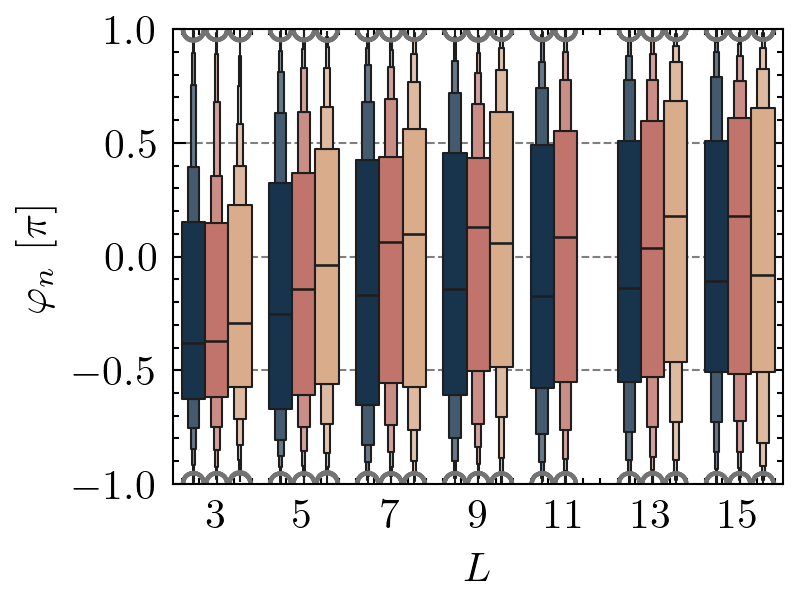

In [240]:
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
ax      = sns.boxenplot(data=df_all, x='N',y='a', hue='t', ax=ax, palette=[cmaps.lipari(0.1), cmaps.lipari(0.6), cmaps.lipari(0.8)], legend=False)
_       = ax.set_xlabel("$L$")
_       = ax.set_ylabel("$\\varphi_n~[\mathrm{\pi}]$")
_       = ax.set_ylim(-1,1)
# _       = ax.legend(['$C_i = 0.28~\mathrm{aF}$','$C_i = 0.07~\mathrm{aF}$'], fontsize='small', loc='upper left')

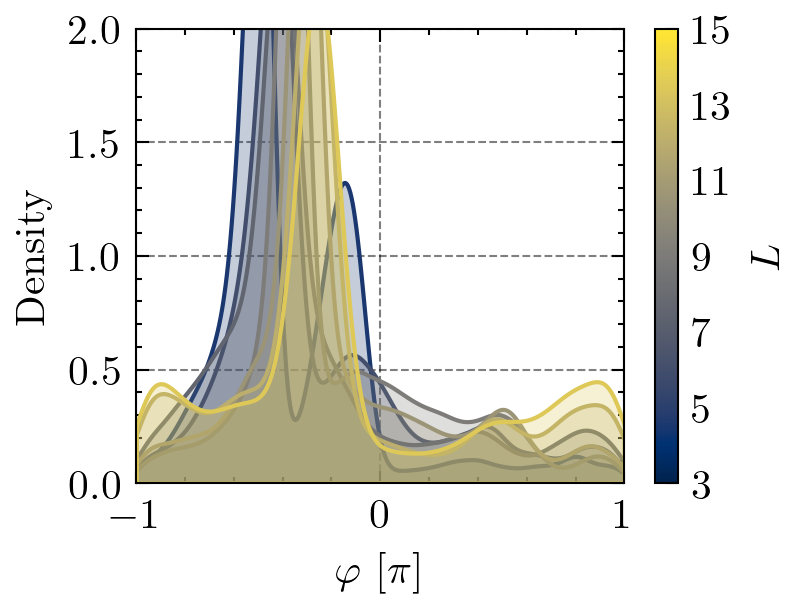

In [148]:
cp      = sns.color_palette('cividis', n_colors=len(N_PARTICLES))
cmap    = plt.get_cmap('cividis')
norm    = mcolors.Normalize(vmin=N_PARTICLES[0],vmax=N_PARTICLES[-1])
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)

for i, N in enumerate(N_PARTICLES):
    df  = pd.DataFrame({'a':phase_vectors[N].flatten(),'b':amp_vectors[N].flatten()})
    ax  = sns.kdeplot(data=df, x='a', ax=ax, weights='b', cut=0, fill=True, bw_adjust=1.0, gridsize=400, color=cp[i])

_ = ax.set_xlabel("$\\varphi~[\mathrm{\pi}]$")
_ = ax.set_xlim(-1,1)
_ = ax.set_ylim(0,2)

sm      = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar    = fig.colorbar(sm, ax=ax, ticks=N_PARTICLES)
_       = cbar.set_label("$L$")
_       = cbar.ax.set_yticklabels([f'{k}' for k in N_PARTICLES])

# fig.savefig(f"plots/pdf/hh_phase_vs_L.pdf", transparent=False)
# fig.savefig(f"plots/svg/hh_phase_vs_L.svg", transparent=True)
# fig.savefig(f"plots/png/hh_phase_vs_L.png", transparent=False)

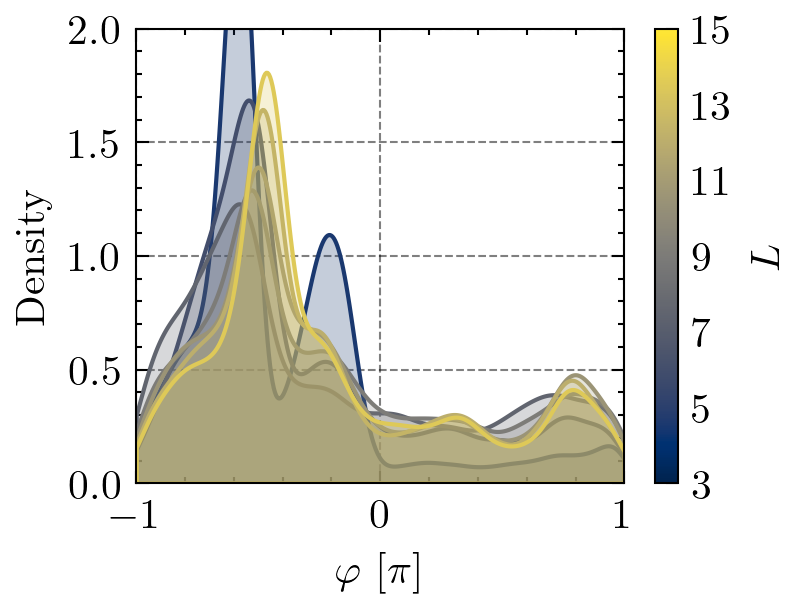

In [149]:
cp      = sns.color_palette('cividis', n_colors=len(N_PARTICLES))
cmap    = plt.get_cmap('cividis')
norm    = mcolors.Normalize(vmin=N_PARTICLES[0],vmax=N_PARTICLES[-1])
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)

for i, N in enumerate(N_PARTICLES):
    df  = pd.DataFrame({'a':phase_vectors_2[N].flatten(),'b':amp_vectors_2[N].flatten()})
    ax  = sns.kdeplot(data=df, x='a', ax=ax, weights='b', cut=0, fill=True, bw_adjust=1.0, gridsize=400, color=cp[i])

_ = ax.set_xlabel("$\\varphi~[\mathrm{\pi}]$")
_ = ax.set_xlim(-1,1)
_ = ax.set_ylim(0,2)

sm      = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar    = fig.colorbar(sm, ax=ax, ticks=N_PARTICLES)
_       = cbar.set_label("$L$")
_       = cbar.ax.set_yticklabels([f'{k}' for k in N_PARTICLES])

# fig.savefig(f"plots/pdf/hh_phase_vs_L_2.pdf", transparent=False)
# fig.savefig(f"plots/svg/hh_phase_vs_L_2.svg", transparent=True)
# fig.savefig(f"plots/png/hh_phase_vs_L_2.png", transparent=False)

### Nonlinear Metrics

In [241]:
def compute_spectral_centroid(amplitudes, harmonic_orders, exclude_fundamental=True):
    """
    Calculates the Spectral Centroid (Center of Mass of the Harmonic Spectrum).
    
    Formula: C = Sum(n * A_n^2) / Sum(A_n^2)
    (Weighted by Power, consistent with energy distribution)
    
    Parameters:
    - amplitudes: Array of magnitudes [A_1, A_3, A_5...]
    - harmonic_orders: Array of harmonic indices [1, 3, 5...]
    - exclude_fundamental: If True, calculates the centroid of the DISTORTION only (n > 1).
                           If False, includes the fundamental frequency.
    
    Returns:
    - centroid: The weighted average harmonic order (e.g., 3.5 means energy is between n=3 and n=5).
    """
    # Ensure inputs are numpy arrays
    amps = np.asarray(amplitudes)
    ords = np.asarray(harmonic_orders)
    
    # 1. Filter: Decide whether to include n=1
    if exclude_fundamental:
        # Only keep harmonics where n > 1
        mask = ords > 1
        valid_amps = amps[mask]
        valid_ords = ords[mask]
    else:
        valid_amps = amps
        valid_ords = ords
        
    # 2. Calculate Power (Square of Amplitude)
    power = valid_amps**2
    total_power = np.sum(power)
    
    # 3. Safety Check for Zero Distortion
    if total_power < 1e-20:
        return np.nan # No harmonic energy exists
        
    # 4. Calculate Centroid
    # Sum(n * Power) / Sum(Power)
    centroid = np.sum(valid_ords * power) / total_power
    
    return centroid

In [242]:
hh_vectors  = {}
dim         = 9
n_vals      = np.arange(1,dim+1,1)
noise_floor = 1
for N in N_PARTICLES:
    hh_vectors[N] = np.array([extract_harmonic_features(data_boot[N][i],n_vals,mode='abs',pad_len=8192,interpolate=True, N_periods=5) for i in range(N_SAMPLES*N_BOOT)])

centr_vals  = {N : [compute_spectral_centroid(hh_vectors[N][i], n_vals) for i in range(N_SAMPLES*N_BOOT) if hh_vectors[N][i,0] > noise_floor] for N in N_PARTICLES}
thd_vals    = {N : [compute_thd(hh_vectors[N][i]) for i in range(N_SAMPLES*N_BOOT) if hh_vectors[N][i,0] > noise_floor] for N in N_PARTICLES}

In [243]:
hh_vectors  = {}
dim         = 9
n_vals      = np.arange(1,dim+1,1)
noise_floor = 1
for N in N_PARTICLES:
    hh_vectors[N] = np.array([extract_harmonic_features(data_boot_2[N][i],n_vals,mode='abs',pad_len=8192,interpolate=True, N_periods=5) for i in range(N_SAMPLES*N_BOOT)])

centr_vals_2  = {N : [compute_spectral_centroid(hh_vectors[N][i], n_vals) for i in range(N_SAMPLES*N_BOOT) if hh_vectors[N][i,0] > noise_floor] for N in N_PARTICLES}
thd_vals_2    = {N : [compute_thd(hh_vectors[N][i]) for i in range(N_SAMPLES*N_BOOT) if hh_vectors[N][i,0] > noise_floor] for N in N_PARTICLES}

In [244]:
hh_vectors  = {}
dim         = 9
n_vals      = np.arange(1,dim+1,1)
noise_floor = 1
for N in N_PARTICLES:
    if N != 11:
        hh_vectors[N] = np.array([extract_harmonic_features(data_boot_3[N][i],n_vals,mode='abs',pad_len=8192,interpolate=True, N_periods=5) for i in range(N_SAMPLES*N_BOOT)])

centr_vals_3  = {N : [compute_spectral_centroid(hh_vectors[N][i], n_vals) for i in range(N_SAMPLES*N_BOOT) if hh_vectors[N][i,0] > noise_floor] for N in N_PARTICLES if N != 11}
thd_vals_3    = {N : [compute_thd(hh_vectors[N][i]) for i in range(N_SAMPLES*N_BOOT) if hh_vectors[N][i,0] > noise_floor] for N in N_PARTICLES if N != 11}

In [245]:
df          = pd.DataFrame(thd_vals).melt()
df['t']     = 1
df2         = pd.DataFrame(thd_vals_2).melt()
df2['t']    = 2
df3         = pd.DataFrame(thd_vals_3).melt()
df3['t']    = 3
df          = pd.concat([df, df2, df3], ignore_index=True)

# df.head()

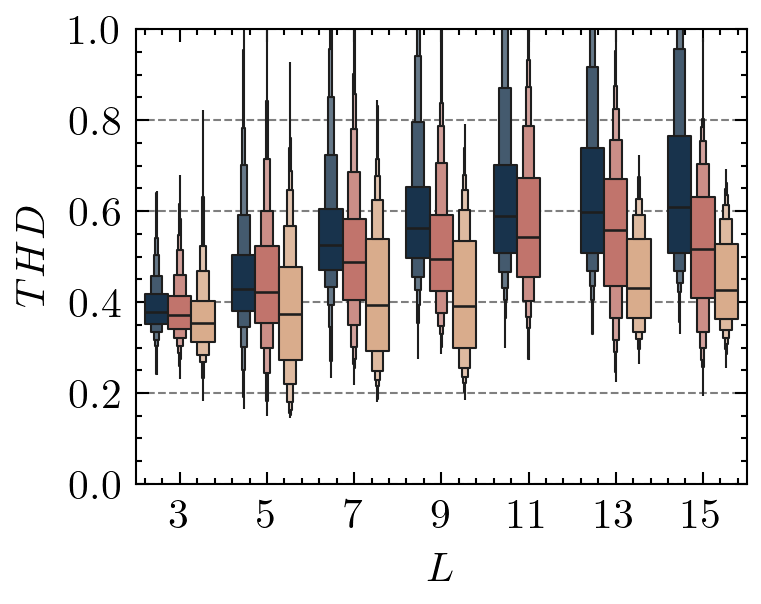

In [247]:
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
# ax      = sns.violinplot(data=df, x='variable', y='value',hue='t', ax=ax, gridsize=300, split=True, inner=None, palette=[cmaps.lipari(0.6), cmaps.lipari(0.1)], density_norm='width', legend=False)
ax      = sns.boxenplot(data=df, x='variable', y='value',hue='t', ax=ax, showfliers=False,
                         palette=[cmaps.lipari(0.1), cmaps.lipari(0.6), cmaps.lipari(0.8)], legend=False)
_       = ax.set_xlabel('$L$')
_       = ax.set_ylabel('$THD$')
_       = ax.set_ylim(0,1)
# _       = ax.legend(['$C_i = 0.28~\mathrm{aF}$','$C_i = 0.07~\mathrm{aF}$'], fontsize='small', loc='upper left')

fig.savefig("plots/png/THD_dist_vs_system_size.png", transparent=False)
fig.savefig("plots/pdf/THD_dist_vs_system_size.pdf", transparent=False)
fig.savefig("plots/svg/THD_dist_vs_system_size.svg", transparent=True)

In [248]:
df          = pd.DataFrame(centr_vals).melt()
df['t']     = 1
df2         = pd.DataFrame(centr_vals_2).melt()
df2['t']    = 2
df3         = pd.DataFrame(centr_vals_3).melt()
df3['t']    = 3
df          = pd.concat([df, df2, df3], ignore_index=True)
df.head()

,variable,value,t
0,3,2.704270,1
1,3,2.678651,1
2,3,2.696850,1
3,3,2.699568,1
4,3,2.674290,1


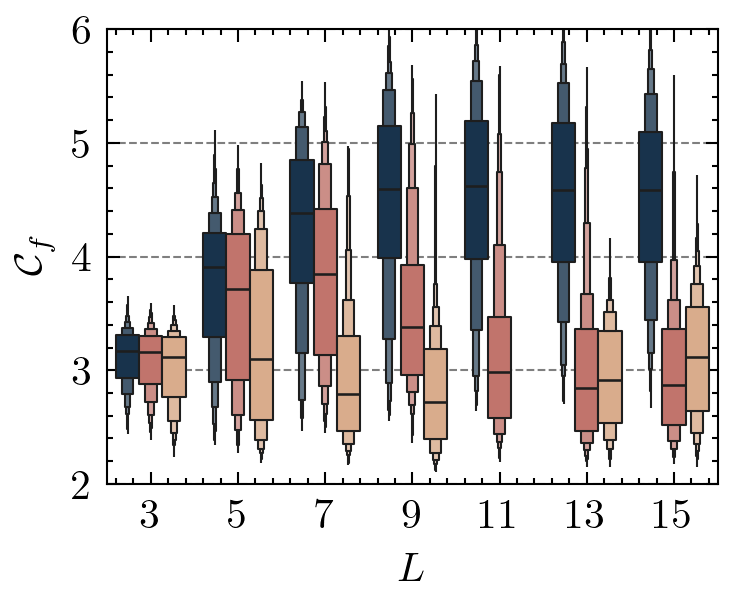

In [250]:
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
# ax      = sns.violinplot(data=df, x='variable', y='value',hue='t', ax=ax, gridsize=300, split=True, inner=None, palette=[cmaps.lipari(0.6), cmaps.lipari(0.1)], density_norm='width', legend=False)
ax      = sns.boxenplot(data=df, x='variable', y='value',hue='t', ax=ax, showfliers=False,
                         palette=[cmaps.lipari(0.1), cmaps.lipari(0.6), cmaps.lipari(0.8)], legend=False)
_       = ax.set_xlabel('$L$')
_       = ax.set_ylabel('$\mathcal{C}_f$')
_       = ax.set_ylim(2,6)
# _       = ax.legend(['$C_i = 0.28~\mathrm{aF}$','$C_i = 0.07~\mathrm{aF}$'], fontsize='small', loc='upper left')

fig.savefig("plots/png/Cf_dist_vs_system_size.png", transparent=False)
fig.savefig("plots/pdf/Cf_dist_vs_system_size.pdf", transparent=False)
fig.savefig("plots/svg/Cf_dist_vs_system_size.svg", transparent=True)

In [251]:
L       = 7
dim     = 8
n_vals  = np.arange(1, dim + 1, 1)
hh_vc   = [extract_harmonic_features(y_2_new[L][i,:-1], n_vals, mode='abs', pad_len=8192, interpolate=True, N_periods=4) for i in range(N_SAMPLES)]
hh_rel  = np.array(hh_vc)/np.tile(np.array(hh_vc)[:,0],(8,1)).T
thds_7  = [compute_thd(extract_harmonic_features(y_2_new[L][i,:-1], n_vals, mode='abs', pad_len=8192, interpolate=True, N_periods=4)) for i in range(N_SAMPLES)]
thd_idx = np.argsort(thds_7)

In [252]:
dim     = 2
n_vals  = np.arange(1, dim + 1, 1)
hh_vc   = [get_phase_lag(y_2_new[L][i,:-1], x_2_new[L][i]) for i in range(N_SAMPLES)]
ph_idx  = np.argsort(hh_vc)

In [253]:
np.sort(hh_vc)

array([-0.20032585, -0.18108694, -0.14528073, -0.13808499, -0.1370741 ,
       -0.13274514, -0.12554051, -0.12201238, -0.11918416, -0.11342785,
       -0.09148482, -0.0754154 , -0.06416594, -0.06359371, -0.06043165,
       -0.05558814, -0.04514936, -0.04271123, -0.03789386, -0.03779839,
       -0.03180519, -0.03161535, -0.01947657, -0.01878845, -0.01618495,
       -0.01179866, -0.00953493, -0.00414169, -0.00359652, -0.00304445,
       -0.00161522,  0.00095128,  0.00264466,  0.0026612 ,  0.00279108,
        0.00778443,  0.00856644,  0.00873178,  0.00930171,  0.00953405,
        0.00994347,  0.01012412,  0.01041944,  0.01158537,  0.0126777 ,
        0.01342382,  0.01380292,  0.01734738,  0.01856063,  0.01859327,
        0.01957269,  0.02028679,  0.02122146,  0.0216767 ,  0.02205995,
        0.02459455,  0.0264161 ,  0.02676986,  0.02691174,  0.02699201,
        0.02943573,  0.02954346,  0.03014037,  0.03165855,  0.03203127,
        0.03217488,  0.03451272,  0.03478492,  0.03500996,  0.03

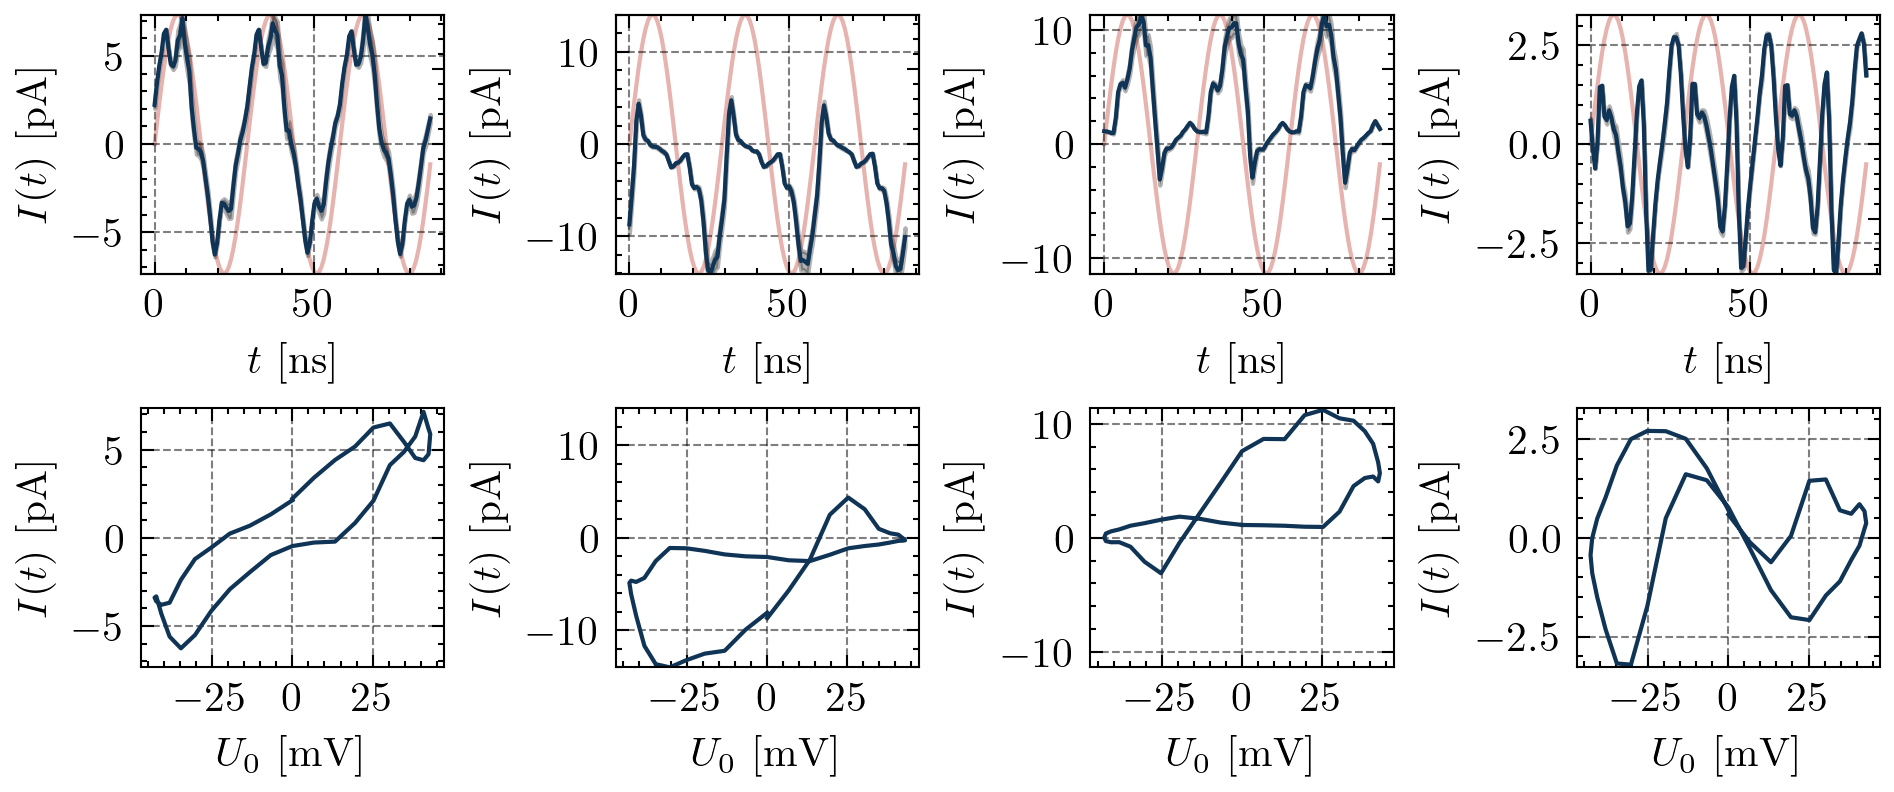

In [256]:
# idx = [thd_idx[0],thd_idx[N_SAMPLES//3],thd_idx[2*N_SAMPLES//3],thd_idx[-2]]
idx = [thd_idx[0],ph_idx[0],ph_idx[1],thd_idx[-1]]
fig = plt.figure(dpi=300, layout='constrained')
_   = fig.set_figwidth(fig.get_figwidth()*1.8)

for i, n in enumerate(idx):

    ax  = fig.add_subplot(2,4,i+1)
    tt  = np.arange(120)*DT[L]*1e9
    xx  = x_2_new[L][n,:120]*1000
    yy  = y_2_new[L][n,:120]*1e-6
    ye  = y_e_2_new[L][n,:120]*1e-6

    _   = ax.plot(tt, yy, color=cmaps.lipari(0.1))
    _   = ax.fill_between(tt, yy-ye, yy+ye, color='black', alpha=0.3)
    _   = ax.set_ylim(-np.max(np.abs(yy)), np.max(np.abs(yy)))
    
    ax2 = ax.twinx()
    _   = ax2.plot(tt, xx, color=cmaps.lipari(0.6), alpha=0.5)
    _   = ax2.set_yticklabels("")
    _   = ax2.set_ylim(-np.max(np.abs(xx)), np.max(np.abs(xx)))
    _   = ax2.grid(False)

    ax.set_zorder(ax2.get_zorder()+1)
    ax.patch.set_visible(False)

    ax.set_ylabel('$I(t)~[\mathrm{pA}]$')
    ax.set_xlabel("$t~[\mathrm{ns}]$")

    ax  = fig.add_subplot(2,4,i+5)
    _   = ax.plot(xx[:41], yy[:41], color=cmaps.lipari(0.1))
    _   = ax.set_ylim(-np.max(np.abs(yy)), np.max(np.abs(yy)))

    ax.set_ylabel('$I(t)~[\mathrm{pA}]$')
    ax.set_xlabel("$U_0~[\mathrm{mV}]$")

    fig.savefig("plots/png/example_responses.png", transparent=False)
    fig.savefig("plots/pdf/example_responses.pdf", transparent=False)
    fig.savefig("plots/svg/example_responses.svg", transparent=True)